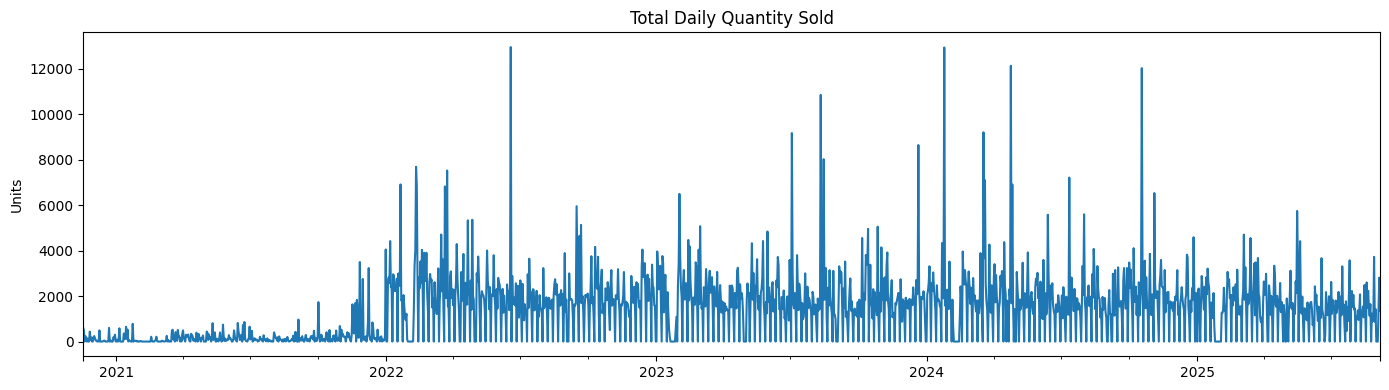

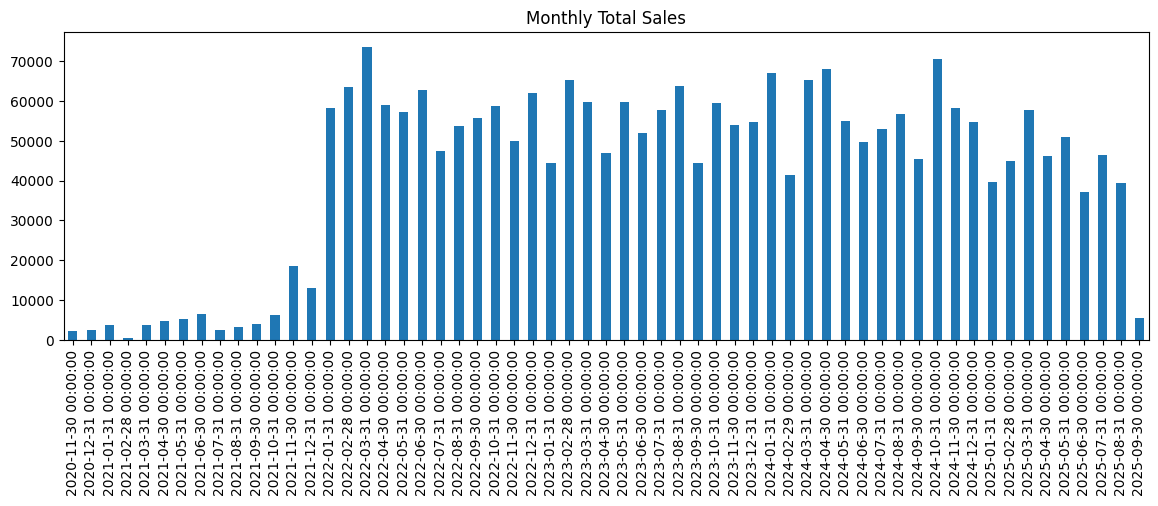

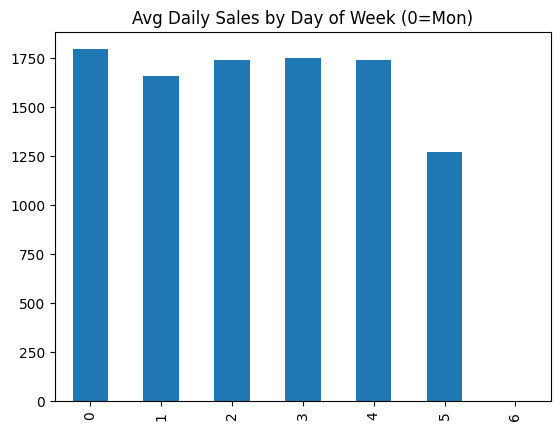

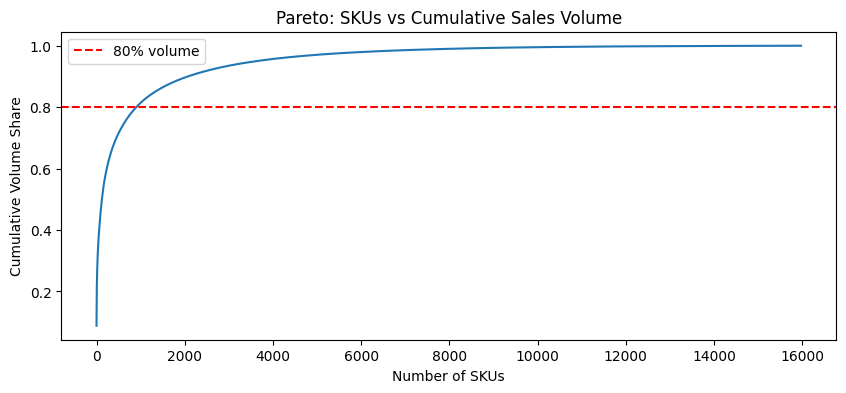

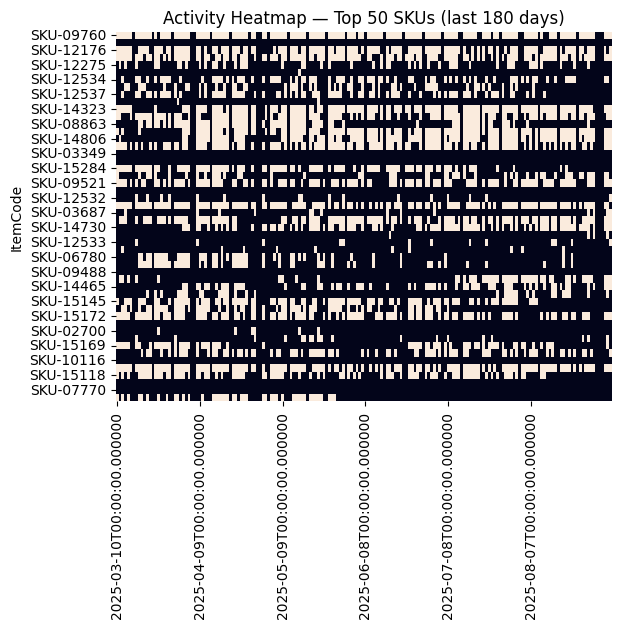

count    15972.000000
mean        29.828825
std         75.301091
min          0.000000
25%          2.000000
50%          6.000000
75%         22.000000
max       1061.000000
dtype: float64
SKUs active > 500 days: 95
SKUs active <  10 days: 9604


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

grid = pd.read_parquet('../data/processed/daily_sales.parquet')

# 1. Overall daily sales trend
grid.sum(axis=1).plot(figsize=(14,4), title='Total Daily Quantity Sold')
plt.ylabel('Units'); plt.tight_layout(); plt.show()

# 2. Monthly seasonality
grid.resample('ME').sum().sum(axis=1).plot(
    kind='bar', figsize=(14,4), title='Monthly Total Sales')
plt.show()

# 3. Day-of-week pattern
pd.Series(grid.sum(axis=1).values,
          index=grid.index).groupby(grid.index.dayofweek).mean().plot(
    kind='bar', title='Avg Daily Sales by Day of Week (0=Mon)')
plt.show()

# 4. Pareto curve
sku_total = grid.sum().sort_values(ascending=False)
cumsum    = sku_total.cumsum() / sku_total.sum()
plt.figure(figsize=(10,4))
plt.plot(range(len(cumsum)), cumsum.values)
plt.axhline(0.8, color='red', linestyle='--', label='80% volume')
plt.xlabel('Number of SKUs')
plt.ylabel('Cumulative Volume Share')
plt.title('Pareto: SKUs vs Cumulative Sales Volume')
plt.legend(); plt.show()

# 5. Sparsity heatmap — top 50 SKUs, last 180 days
top50 = sku_total.head(50).index
sns.heatmap((grid[top50].iloc[-180:] > 0).T, cbar=False, xticklabels=30)
plt.title('Activity Heatmap — Top 50 SKUs (last 180 days)')
plt.show()

# 6. SKU activity stats
days_active = (grid > 0).sum()
print(days_active.describe())
print("SKUs active > 500 days:", (days_active > 500).sum())
print("SKUs active <  10 days:", (days_active < 10).sum())